In [1]:
!pip install timm

In [2]:
DATA_ROOT = "/content/drive/MyDrive/MOD"

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
# Data augmentation pipelines
# Training set gets flips and rotations for robustness
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],  # ImageNet normalization
                         [0.229,0.224,0.225])
])

# Validation/test - no augmentation, just normalization
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Load dataset splits from directory structure
train_dataset = datasets.ImageFolder(f"{DATA_ROOT}/train_augmented", transform=train_transform)
val_dataset   = datasets.ImageFolder(f"{DATA_ROOT}/validate", transform=val_transform)
test_dataset  = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=val_transform)

batch_size = 8  # Conservative batch size - works on free tier GPUs

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

num_classes = 7

print("Classes:", train_dataset.classes)

Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [5]:
# ===== EFFICIENTNET CNN BACKBONE =====
# Extract multiscale feature maps from EfficientNet-B0
class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.efficientnet_b0(pretrained=True)
        self.features = base.features

    def forward(self, x):
        # Get intermediate feature maps at different depths
        x = self.features[0](x)
        x = self.features[1](x)
        F1 = self.features[2](x)  # Lower resolution features
        F2 = self.features[3](F1)  # Mid-level features
        F3 = self.features[4:](F2)  # High-level semantics
        return F1, F2, F3


# ===== VISION TRANSFORMER BRANCH =====
class ViTBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model(
            'vit_small_patch16_224',
            pretrained=True,
            num_classes=0  # Get embeddings only
        )

    def forward(self, x):
        # Extract [CLS] token representation
        tokens = self.vit.forward_features(x)
        return tokens[:, 0]  # Return CLS token


# ===== DISAGREEMENT-BASED FUSION MODULE =====
# Core contribution: dynamically weight CNN and ViT contributions based on prediction agreement
class DisagreementFusion(nn.Module):
    def __init__(self, cnn_dim, vit_dim, num_classes):
        super().__init__()

        # Auxiliary classifiers for disagreement estimation
        self.cnn_aux = nn.Linear(cnn_dim, num_classes)
        self.vit_aux = nn.Linear(vit_dim, num_classes)

        # Sigmoid parameters - learned disagreement to weight factor mapping
        self.w_d = nn.Parameter(torch.tensor(1.0))
        self.b_d = nn.Parameter(torch.tensor(-0.5))

        # Projection layers for fusion space
        self.phi = nn.Linear(cnn_dim + vit_dim, 512)
        self.raw_proj = nn.Linear(cnn_dim + vit_dim, 512)

    def forward(self, h_cnn, h_vit):
        # Get separate predictions from each modality
        cnn_logits = self.cnn_aux(h_cnn)
        vit_logits = self.vit_aux(h_vit)

        # Convert to probabilities
        Pcnn = F.softmax(cnn_logits, dim=1)
        Pvit = F.softmax(vit_logits, dim=1)

        # Calculate L1 disagreement between modalities
        D = torch.sum(torch.abs(Pcnn - Pvit), dim=1, keepdim=True)
        # Scale disagreement to fusion weight [0, 1]
        alpha = torch.sigmoid(self.w_d * D + self.b_d)

        # Concatenate features from both branches
        raw = torch.cat([h_cnn, h_vit], dim=1)

        # Project to shared space with nonlinearity
        Phi = F.relu(self.phi(raw))
        # Also keep raw projection as alternative path
        raw_proj = self.raw_proj(raw)

        # Blend between two fusion pathways based on disagreement
        fused = alpha * Phi + (1 - alpha) * raw_proj

        return fused, cnn_logits, vit_logits


# ===== MAIN ARCHITECTURE =====
# OrCanNet - combines CNN and ViT with inteligent fusion mechanism
class OrCanNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = EfficientNetBackbone()
        self.vit = ViTBranch()
        self.fusion = DisagreementFusion(1280, 384, num_classes)

        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        # CNN pathway
        _, _, F3 = self.cnn(x)
        h_cnn = torch.flatten(F.adaptive_avg_pool2d(F3,1),1)

        # ViT pathway
        h_vit = self.vit(x)

        # Fusion with disagreement weighting
        fused, cnn_logits, vit_logits = self.fusion(h_cnn, h_vit)
        fused = self.dropout(fused)

        # Final classification
        out = self.classifier(fused)
        return out, cnn_logits, vit_logits

In [6]:
# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = OrCanNet(num_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 20
lambda_aux = 0.2  # Weight for auxiliary losses from CNN and ViT branches


def compute_loss(out, cnn_logits, vit_logits, labels):
    """
    Multi-task loss combining main classifier with auxiliary outputs.
    This helps regularize the intermediate modality-specific classifiers
    and ensures both CNN and ViT branches remain discrimitive.
    """
    main = F.cross_entropy(out, labels)
    aux1 = F.cross_entropy(cnn_logits, labels)
    aux2 = F.cross_entropy(vit_logits, labels)
    return main + lambda_aux*(aux1 + aux2)


# Training loop - standard SGD-style optimization
for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        out, cnn_logits, vit_logits = model(images)
        loss = compute_loss(out, cnn_logits, vit_logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation phase - evaluate on held-out validation set
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out,_,_ = model(images)
            preds = torch.argmax(out,1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-"*40)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Epoch 1
Train Loss: 1.2967
Validation Accuracy: 0.6000
----------------------------------------
Epoch 2
Train Loss: 0.2964
Validation Accuracy: 0.6909
----------------------------------------
Epoch 3
Train Loss: 0.1673
Validation Accuracy: 0.6545
----------------------------------------
Epoch 4
Train Loss: 0.0781
Validation Accuracy: 0.6727
----------------------------------------
Epoch 5
Train Loss: 0.0785
Validation Accuracy: 0.6727
----------------------------------------
Epoch 6
Train Loss: 0.0539
Validation Accuracy: 0.6545
----------------------------------------
Epoch 7
Train Loss: 0.0303
Validation Accuracy: 0.6364
----------------------------------------
Epoch 8
Train Loss: 0.0984
Validation Accuracy: 0.6364
----------------------------------------
Epoch 9
Train Loss: 0.0967
Validation Accuracy: 0.6182
----------------------------------------
Epoch 10
Train Loss: 0.0577
Validation Accuracy: 0.6909
----------------------------------------
Epoch 11
Train Loss: 0.0439
Validation 

In [7]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/MOD/orcannet_model.pth"

torch.save(model.state_dict(), MODEL_SAVE_PATH)

print("Model saved successfully!")

Model saved successfully!


              precision    recall  f1-score   support

         CaS       0.78      0.88      0.82         8
         CoS       0.89      1.00      0.94         8
         Gum       0.78      1.00      0.88         7
          MC       0.75      0.67      0.71         9
          OC       0.67      0.67      0.67         6
         OLP       1.00      0.60      0.75        10
          OT       0.57      0.67      0.62         6

    accuracy                           0.78        54
   macro avg       0.78      0.78      0.77        54
weighted avg       0.80      0.78      0.77        54



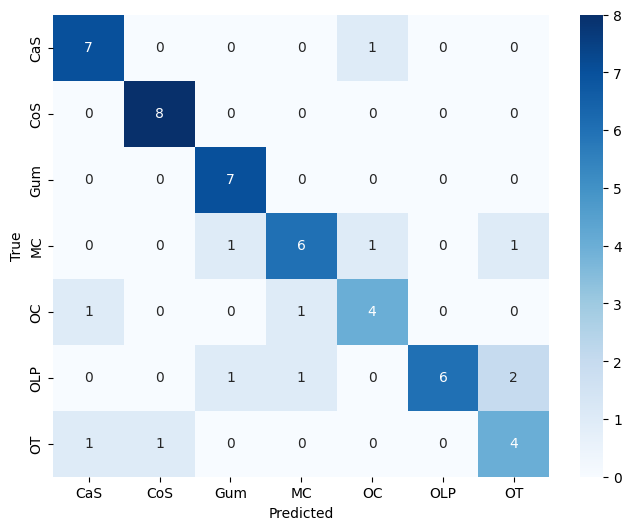

In [8]:
# Evaluate on test set and generate classification metrics
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        out,_,_ = model(images)
        preds = torch.argmax(out,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Compute and visualize confussion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [14]:
# ===== GRADIENT-BASED INTERPRETABILITY FOR CNN =====
# Grad-CAM visualization to understand which image regions the CNN focuses on
import cv2
import numpy as np

def generate_cnn_gradcam(model, image, target_class):
    """
    Generate Grad-CAM heatmap for CNN branch.
    This shows which pixels contribute to the CNN's classification descision.
    """
    model.eval()
    image = image.unsqueeze(0).to(device)

    activations = []
    gradients = []

    # Register hooks to capture intermediate values
    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.cnn.features[-1]

    handle_fwd = target_layer.register_forward_hook(forward_hook)
    handle_bwd = target_layer.register_full_backward_hook(backward_hook)

    # Forward and backward pass
    output, _, _ = model(image)
    loss = output[0, target_class]

    model.zero_grad()
    loss.backward()

    # Extract attention weights
    grads = gradients[0]
    acts = activations[0]

    # Weight each channel by its gradient
    weights = torch.mean(grads, dim=(2,3), keepdim=True)
    cam = torch.sum(weights * acts, dim=1)

    # Apply ReLU to get positive contributions only
    cam = F.relu(cam)
    cam = cam.squeeze().cpu().detach().numpy()

    # Resize to original image dimensions for visualization
    cam = cv2.resize(cam, (224,224))
    cam = cam / (cam.max() + 1e-8)

    # Cleanup
    handle_fwd.remove()
    handle_bwd.remove()

    return cam

In [35]:
# ===== ATTENTION ROLLOUT FOR VISION TRANSFORMER =====
# Extract and aggregate attention weights from ViT layers
def generate_vit_attention_map(model, image):
    """
    Generate attention visualization by aggregating cross-attention maps.
    Shows how ViT patches attend to each other and which regions affect the [CLS] token.
    Note: This is a simplified version - full rollout implmentation can be more complex.
    """
    model.eval()
    image = image.unsqueeze(0).to(device)

    vit_model = model.vit.vit
    attn_maps = []

    original_forwards = []

    # Monkey-patch attention modules to capture attention weights
    for blk in vit_model.blocks:

        original_forwards.append(blk.attn.forward)

        def modified_forward(self, x, attn_mask=None):

            B, N, C = x.shape

            qkv = self.qkv(x)
            qkv = qkv.reshape(B, N, 3, self.num_heads, C // self.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)

            q, k, v = qkv[0], qkv[1], qkv[2]

            # Compute scaled dot-product attention
            attn = (q @ k.transpose(-2, -1)) * self.scale

            if attn_mask is not None:
                attn = attn + attn_mask

            attn = attn.softmax(dim=-1)

            # Store for later analisys
            attn_maps.append(attn.detach())

            # Standard attention output
            x = (attn @ v).transpose(1, 2).reshape(B, N, C)
            x = self.proj(x)
            x = self.proj_drop(x)

            return x

        # Replace method in instance
        blk.attn.forward = modified_forward.__get__(blk.attn, type(blk.attn))

    # Forward pass to trigger attention capture
    with torch.no_grad():
        _ = model(image)

    # Restore original implementations
    for blk, orig in zip(vit_model.blocks, original_forwards):
        blk.attn.forward = orig

    if len(attn_maps) == 0:
        raise RuntimeError("Attention extraction failed.")

    # Use last block's attention (closest to classification)
    attn = attn_maps[-1][0]  # Remove batch dimension
    attn = attn.mean(dim=0)  # Average across attention heads

    cls_attn = attn[0, 1:]  # Extract [CLS] token's attention to patch tokens

    # Reconstruct spatial layout (assumes square patch grid)
    size = int(cls_attn.shape[0] ** 0.5)

    attn_map = cls_attn.reshape(size, size).cpu().numpy()
    attn_map = cv2.resize(attn_map, (224, 224))
    attn_map = attn_map / (attn_map.max() + 1e-8)

    return attn_map

In [36]:
# ===== FUSION-LEVEL INTERPRETABILITY =====
def generate_fusion_heatmap(model, image, target_class):
    """
    Combine CNN Grad-CAM and ViT attention using the learned fusion weights.
    The disagreement-based alpha determines the blend between modalities.
    This shows how the model interprets evidence from both vision modalities.
    """
    model.eval()
    image_batch = image.unsqueeze(0).to(device)

    with torch.no_grad():
        # Get predictions and compute disagreement
        out, cnn_logits, vit_logits = model(image_batch)

        Pcnn = F.softmax(cnn_logits, dim=1)
        Pvit = F.softmax(vit_logits, dim=1)

        # L1 distance between probability distributions
        D = torch.sum(torch.abs(Pcnn - Pvit), dim=1, keepdim=True)
        # Learned mapping from disagreement to fusion weight
        alpha = torch.sigmoid(
            model.fusion.w_d * D + model.fusion.b_d
        ).item()

    # Generate interpretability maps for both branches
    cnn_map = generate_cnn_gradcam(model, image, target_class)
    vit_map = generate_vit_attention_map(model, image)

    # Fuse using same weight as model does internally
    fusion_map = alpha * cnn_map + (1 - alpha) * vit_map
    fusion_map = fusion_map / (fusion_map.max() + 1e-8)

    return cnn_map, vit_map, fusion_map

In [37]:
# Helper function to overlay heatmap on original image
def overlay_heatmap(image_tensor, heatmap, title):
    """
    Visualize heatmap overlayed on orignal image using jet colormap.
    """
    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    heatmap_color = cv2.applyColorMap(
        np.uint8(255*heatmap),
        cv2.COLORMAP_JET
    )
    heatmap_color = heatmap_color / 255.0

    # Blend image and heatmap
    overlay = 0.6*img + 0.4*heatmap_color
    overlay = overlay / overlay.max()

    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [38]:
# Load pretrained model for inference
model = OrCanNet(num_classes=7).to(device)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/MOD/orcannet_model.pth",
    map_location=device
))
model.eval()

print("Model loaded and ready for visualization")

OrCanNet(
  (cnn): EfficientNetBackbone(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_

In [103]:
# Comprehensive visualisation function - show all interpretability maps
import matplotlib.pyplot as plt
import numpy as np

def show_all_maps(model, image_tensor, test_dataset):
    """
    Generate side-by-side visualization of:
    1. Original image
    2. CNN Grad-CAM heatmap
    3. ViT attention map
    4. Fusion heatmap (weighted combination)

    This allows direct comparison of what each modality attends to.
    """
    model.eval()
    image = image_tensor.to(device)

    # Get model prediction
    with torch.no_grad():
        out, _, _ = model(image.unsqueeze(0))
        pred = torch.argmax(out, 1).item()

    # Generate all heatmaps
    cnn_map, vit_map, fusion_map = generate_fusion_heatmap(
        model,
        image,
        pred
    )

    # Prepare normalized image for display
    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    # Create multi-panel figure
    fig, axs = plt.subplots(1, 4, figsize=(18,5))

    # Panel 1: Original image
    axs[0].imshow(img)
    axs[0].set_title("Original\nTrue:OLP\nPred:OLP")
    axs[0].axis("off")

    # Panel 2: CNN Grad-CAM
    axs[1].imshow(img)
    axs[1].imshow(cnn_map, cmap="jet", alpha=0.5)
    axs[1].set_title("CNN Grad-CAM")
    axs[1].axis("off")

    # Panel 3: ViT Attention
    axs[2].imshow(img)
    axs[2].imshow(vit_map, cmap="jet", alpha=0.5)
    axs[2].set_title("ViT Attention")
    axs[2].axis("off")

    # Panel 4: Fused interpretability
    axs[3].imshow(img)
    axs[3].imshow(fusion_map, cmap="jet", alpha=0.5)
    axs[3].set_title("Fusion Heatmap")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

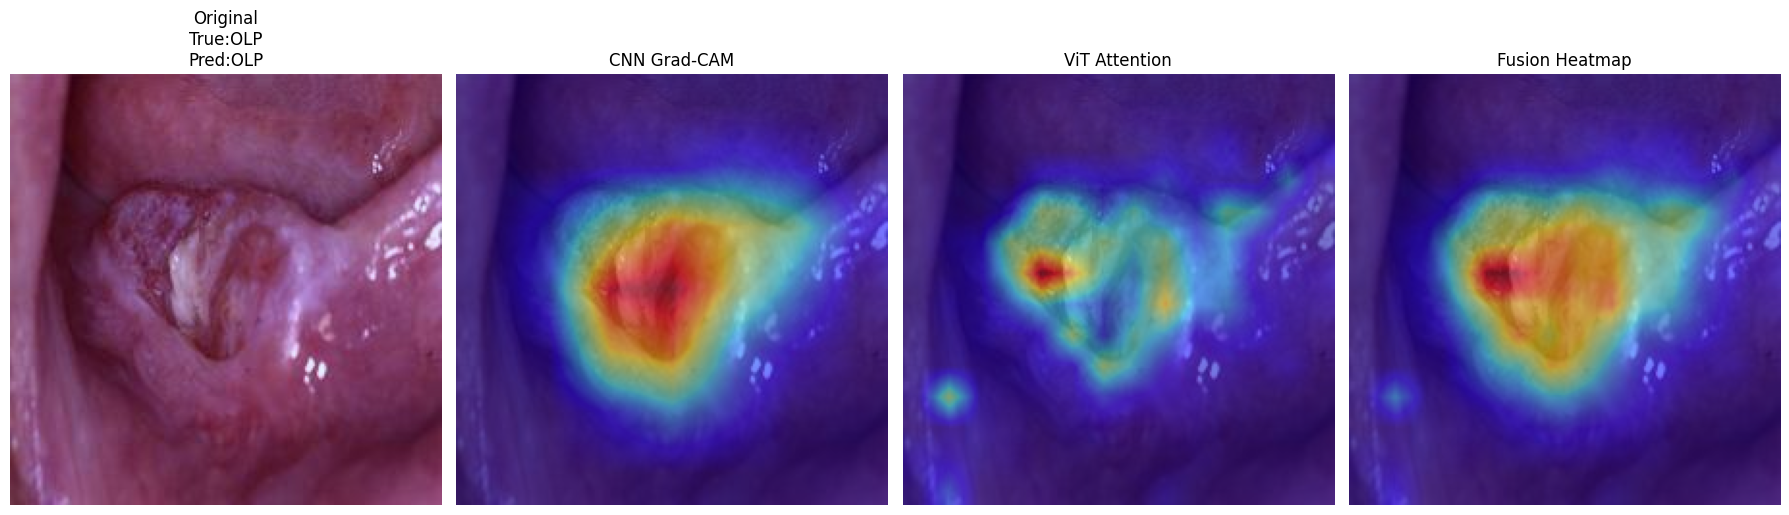

In [104]:
image, label = test_dataset[38]
show_all_maps(model, image, test_dataset)